In [ ]:
from dolfinx import fem,la,mesh,plot
from mpi4py import MPI
import ufl
import numpy as np


In [ ]:
length,height = 10,10
Nx , Ny = 60,60
# corners of the domain 
extent = [[0.0,0.0],[length,height]]

domain = mesh.create_rectangle(MPI.COMM_SELF,extent,[Nx,Ny],mesh.CellType.quadrilateral)


# Setting Variational Problem
$$ \partial_tc_t(X) = D \nabla^2c_t(X)$$

$$
\partial_tc_t(X) = D \nabla^2c_t(X) + \text{source term}
$$
$$
\quad \text{source term is } \alpha_tG_{R_t}(x-X_t) 
$$


$$ \partial_tc_t(X) = D \nabla^2c_t(X) + \alpha_tG_{R_t}(x-X_t)$$

$$
\frac{\partial c_t(\mathbf x)}{\partial n}=0
\quad \text{on } \partial\Omega
$$





In [ ]:
V = fem.functionspace(domain,('Lagrange',1))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

dt = 0.05
D = 72


a = (u*v + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))) * ufl.dx

L = (un*v) * ufl.dx

def initial_condition(x):
    return np.exp(
        -((x[0]-0.5)**2 + (x[1]-0.5)**2)/0.02
    )


In [15]:
from mpi4py import MPI
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem
import ufl
import numpy as np
from petsc4py.PETSc import ScalarType

# Mesh
domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    50, 50
)

# Function space
V = fem.functionspace(domain, ("Lagrange", 1))

# Initial condition
def initial_condition(x):
    return np.exp(
        -((x[0]-0.5)**2 + (x[1]-0.5)**2)/0.02
    )

# Previous timestep solution
un = fem.Function(V)
un.interpolate(initial_condition)

# Unknown and test function
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Parameters
dt = fem.Constant(domain, ScalarType(0.05))
D = fem.Constant(domain, ScalarType(72.0))

# Variational formulation
a = (
    u*v
    + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (un*v) * ufl.dx

# Solution function
uh = fem.Function(V)

# Linear problem
problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)
# Time loop
T = 1.0
t = 0.0

while t < T:

    t += float(dt.value)

    # Solve
    problem.solve()

    # Update previous solution
    un.x.array[:] = uh.x.array


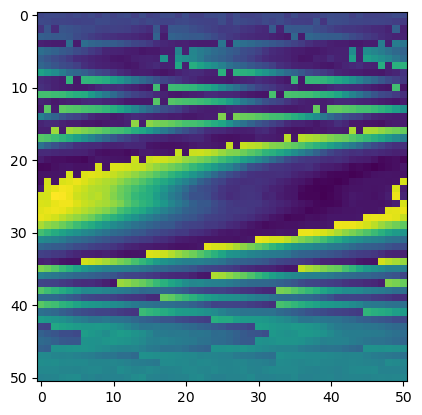

In [20]:
import matplotlib.pyplot as plt 
plt.imshow(un.x.array.reshape(51,51))


In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib as mpl

# -----------------------------
# Mesh
# -----------------------------
domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    50,
    50
)

# -----------------------------
# Function space
# -----------------------------
V = fem.functionspace(domain, ("Lagrange", 1))

# -----------------------------
# Initial condition
# -----------------------------
def initial_condition(x):
    return np.exp(
        -((x[0] - 0.5)**2 + (x[1] - 0.5)**2) / 0.02
    )

# Previous timestep solution
un = fem.Function(V)
un.interpolate(initial_condition)

# Current solution
uh = fem.Function(V)

# -----------------------------
# Variational formulation
# -----------------------------
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

dt = fem.Constant(domain, ScalarType(0.01))
D = fem.Constant(domain, ScalarType(0.1))

a = (
    u * v
    + dt * D * ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (un * v) * ufl.dx

# -----------------------------
# Linear solver
# -----------------------------
problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# -----------------------------
# PyVista setup
# -----------------------------
topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter()

viridis = mpl.colormaps["viridis"]

plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 1]
)

plotter.view_xy()

# Open animation file
plotter.open_gif("diffusion.gif")

# -----------------------------
# Time stepping
# -----------------------------
T = 1.0
t = 0.0

while t < T:

    t += float(dt.value)

    # Solve PDE
    problem.solve()

    # Update previous solution
    un.x.array[:] = uh.x.array

    # Update visualization
    grid.point_data["u"][:] = uh.x.array

    # Write frame
    plotter.write_frame()

# Close animation
plotter.close()


In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm
from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    80,
    80
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Variational formulation
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.02))
D = fem.Constant(domain, ScalarType(0.005))

alpha = 0.5
R = 0.02

# Spatial coordinates
x = ufl.SpatialCoordinate(domain)

# =========================================================
# Initial source position
# =========================================================

X0 = 0.5
Y0 = 0.5

# Moving Gaussian source
source = alpha * (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

# =========================================================
# Weak form
# =========================================================

a = (
    u * v
    + dt * D * ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (
    un * v
    + dt * source * v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# PyVista visualization
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter()

viridis = mpl.colormaps["viridis"]

plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.2]
)

plotter.view_xy()

plotter.open_gif("moving_source2.gif")

# =========================================================
# Time stepping
# =========================================================
# =========================================================
# Time stepping
# =========================================================

T = 10.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Prescribed source trajectory
    # =====================================================

    X0 = 0.5 + 0.35 * np.cos(t)
    Y0 = 0.5 + 0.35 * np.sin(t)

    # =====================================================
    # Update source term
    # =====================================================

    source = alpha * (
        1 / (2 * np.pi * R**2)
    ) * ufl.exp(
        -(
            (x[0] - X0)**2
            + (x[1] - Y0)**2
        ) / (2 * R**2)
    )

    # =====================================================
    # Update RHS
    # =====================================================

    L = (
        un * v
        + dt * source * v
    ) * ufl.dx

    # Rebuild problem with updated source
    problem = LinearProblem(
        a,
        L,
        u=uh,
        petsc_options_prefix="diffusion_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu"
        }
    )

    # Solve PDE
    problem.solve()

    # Update previous timestep
    un.x.array[:] = uh.x.array

    # Update visualization
    grid.point_data["u"][:] = uh.x.array

    plotter.write_frame()


100%|██████████| 500/500 [03:57<00:00,  2.10it/s]


In [ ]:
plotter.close()


In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    80,
    80
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial and test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.03))

D = fem.Constant(domain, ScalarType(0.001))

# Decay parameter
lam = fem.Constant(domain, ScalarType(0.8))

# Source strength
alpha = 0.1

# Gaussian width
R = 0.0015

# Angular frequency
omega = .30

# Spatial coordinates
x = ufl.SpatialCoordinate(domain)

# =========================================================
# Initial source position
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.5))
Y0 = fem.Constant(domain, ScalarType(0.5))

# =========================================================
# Gaussian source
# =========================================================

source = alpha * (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

# =========================================================
# Weak form
# =========================================================

a = (
    u * v
    + dt * D * ufl.dot(ufl.grad(u), ufl.grad(v))
    + dt * lam * u * v
) * ufl.dx

L = (
    un * v
    + dt * source * v
) * ufl.dx

# =========================================================
# Initial linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# PyVista visualization
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter()

viridis = mpl.colormaps["viridis"]

plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.12]
)

plotter.view_xy()

plotter.open_gif("moving_decay_source.gif")

# =========================================================
# Time stepping
# =========================================================

T = 40.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Prescribed circular trajectory
    # =====================================================

    X0.value = ScalarType(0.5 + 0.35*np.cos(omega*t))
    Y0.value = ScalarType(0.5 + 0.35*np.sin(omega*t))

    # =====================================================
    # Update Gaussian source
    # =====================================================

    # =====================================================
    # Solve PDE
    # =====================================================

    problem.solve()

    # =====================================================
    # Update previous timestep
    # =====================================================

    un.x.array[:] = uh.x.array

    # =====================================================
    # Update visualization
    # =====================================================

    grid.point_data["u"][:] = uh.x.array

    plotter.write_frame()

# =========================================================
# Finalize animation
# =========================================================

plotter.close()


100%|██████████| 1333/1333 [01:05<00:00, 20.39it/s]


In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

Nx = 60
Ny = 60

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    Nx,
    Ny
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial and test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.02))

# Diffusion coefficient
D = fem.Constant(domain, ScalarType(0.003))

# Source strength
alpha = 0.15

# Gaussian width
R = 0.012

# Particle mobility
kappa = 0.03

# =========================================================
# Particle position
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.7))
Y0 = fem.Constant(domain, ScalarType(0.5))

# =========================================================
# Spatial coordinates
# =========================================================

x = ufl.SpatialCoordinate(domain)

# =========================================================
# Moving Gaussian source
# =========================================================

source = alpha * (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

# =========================================================
# Weak form
# =========================================================

a = (
    u*v
    + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (
    un*v
    + dt*source*v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# Visualization setup
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter()

viridis = mpl.colormaps["viridis"]

plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.05]
)

plotter.view_xy()

plotter.open_gif("active_particle_no_decay.gif")

# =========================================================
# DOF coordinates
# =========================================================

coords = V.tabulate_dof_coordinates()

# =========================================================
# Time stepping
# =========================================================

T = 6.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Solve PDE
    # =====================================================

    problem.solve()

    # =====================================================
    # Update previous solution
    # =====================================================

    un.x.array[:] = uh.x.array

    # =====================================================
    # Compute approximate gradient at particle
    # =====================================================

    values = uh.x.array

    eps = 0.02

    x0 = float(X0.value)
    y0 = float(Y0.value)

    right = np.argmin(
        (coords[:,0] - (x0 + eps))**2
        + (coords[:,1] - y0)**2
    )

    left = np.argmin(
        (coords[:,0] - (x0 - eps))**2
        + (coords[:,1] - y0)**2
    )

    up = np.argmin(
        (coords[:,0] - x0)**2
        + (coords[:,1] - (y0 + eps))**2
    )

    down = np.argmin(
        (coords[:,0] - x0)**2
        + (coords[:,1] - (y0 - eps))**2
    )

    # Numerical gradient
    dc_dx = (values[right] - values[left]) / (2 * eps)
    dc_dy = (values[up] - values[down]) / (2 * eps)

    # =====================================================
    # Particle dynamics
    # =====================================================

    Xnew = x0 - kappa * float(dt.value) * dc_dx
    Ynew = y0 - kappa * float(dt.value) * dc_dy

    # =====================================================
    # Reflecting walls
    # =====================================================

    Xnew = np.clip(Xnew, 0.05, 0.95)
    Ynew = np.clip(Ynew, 0.05, 0.95)

    X0.value = ScalarType(Xnew)
    Y0.value = ScalarType(Ynew)

    # =====================================================
    # Update visualization
    # =====================================================

    grid.point_data["u"][:] = uh.x.array

    plotter.write_frame()

# =========================================================
# Finish animation
# =========================================================

plotter.close()


 33%|███▎      | 99/300 [00:03<00:06, 29.36it/s]

In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

Nx = 140
Ny = 140

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    Nx,
    Ny
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial / test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.002))

# Diffusion
D = fem.Constant(domain, ScalarType(0.015))

# Emission strength
alpha = 0.0005

# Source width
R = 0.002

# Self-propulsion coupling
beta = 25.0

# Noise amplitude
sigma = 0.12

# =========================================================
# Particle position
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.55))
Y0 = fem.Constant(domain, ScalarType(0.50))

# =========================================================
# Spatial coordinates
# =========================================================

x = ufl.SpatialCoordinate(domain)

# =========================================================
# Gaussian source
# =========================================================

G = (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

source = alpha * G

# =========================================================
# Weak form
# =========================================================

a = (
    u*v
    + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (
    un*v
    + dt*source*v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# Force integrals
# =========================================================

Fx_form = fem.form(
    G * ufl.grad(uh)[0] * ufl.dx
)

Fy_form = fem.form(
    G * ufl.grad(uh)[1] * ufl.dx
)

# =========================================================
# PyVista visualization
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter(
    off_screen=True
)

viridis = mpl.colormaps["viridis"]

actor = plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.002]
)

plotter.view_xy()

plotter.open_gif("active_droplet_prl_style.gif")

# =========================================================
# Trajectory storage
# =========================================================

trajectory_x = []
trajectory_y = []

# =========================================================
# Time stepping
# =========================================================

T = 8.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Solve PDE
    # =====================================================

    problem.solve()

    # =====================================================
    # Update previous solution
    # =====================================================

    un.x.array[:] = uh.x.array

    # =====================================================
    # Compute propulsion force
    # =====================================================

    Fx = fem.assemble_scalar(Fx_form)
    Fy = fem.assemble_scalar(Fy_form)

    # =====================================================
    # Brownian noise
    # =====================================================

    noise_x = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    noise_y = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    # =====================================================
    # Particle dynamics
    # =====================================================

    Xnew = (
        float(X0.value)
        - beta * float(dt.value) * Fx
        + noise_x
    )

    Ynew = (
        float(Y0.value)
        - beta * float(dt.value) * Fy
        + noise_y
    )

    # =====================================================
    # Reflecting boundaries
    # =====================================================

    if Xnew < 0:
        Xnew = -Xnew

    if Xnew > 1:
        Xnew = 2 - Xnew

    if Ynew < 0:
        Ynew = -Ynew

    if Ynew > 1:
        Ynew = 2 - Ynew

    X0.value = ScalarType(Xnew)
    Y0.value = ScalarType(Ynew)

    # =====================================================
    # Store trajectory
    # =====================================================

    trajectory_x.append(Xnew)
    trajectory_y.append(Ynew)

    # =====================================================
    # Update visualization
    # =====================================================

    scalars = uh.x.array

    grid.point_data["u"][:] = scalars

    actor.mapper.scalar_range = (
        0,
        max(np.max(scalars), 1e-8)
    )

    plotter.write_frame()

# =========================================================
# Finish animation
# =========================================================

plotter.close()

# =========================================================
# Trajectory plot
# =========================================================

trajectory_x = np.array(trajectory_x)
trajectory_y = np.array(trajectory_y)

plt.figure(figsize=(8,8))

plt.plot(
    trajectory_x,
    trajectory_y,
    linewidth=1
)

plt.xlim(0,1)
plt.ylim(0,1)

plt.gca().set_aspect("equal")

plt.title("Active droplet trajectory")

plt.show()


100%|██████████| 4000/4000 [07:59<00:00,  8.35it/s]


In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

Nx = 220
Ny = 220

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    Nx,
    Ny
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial / test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.0015))

# Smaller diffusion -> thinner trail
D = fem.Constant(domain, ScalarType(0.003))

# Emission strength
alpha = 0.00012

# Very narrow source
R = 0.0008

# Self propulsion
beta = 40.0

# Less random wandering
sigma = 0.02

# Trail decay
lam = fem.Constant(domain, ScalarType(0.35))

# =========================================================
# Particle position
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.50))
Y0 = fem.Constant(domain, ScalarType(0.50))

# =========================================================
# Spatial coordinates
# =========================================================

x = ufl.SpatialCoordinate(domain)

# =========================================================
# Gaussian source
# =========================================================

G = (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

source = alpha * G

# =========================================================
# Weak form
# =========================================================

a = (
    u*v
    + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))
    + dt*lam*u*v
) * ufl.dx

L = (
    un*v
    + dt*source*v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# Force integrals
# =========================================================

Fx_form = fem.form(
    G * ufl.grad(uh)[0] * ufl.dx
)

Fy_form = fem.form(
    G * ufl.grad(uh)[1] * ufl.dx
)

# =========================================================
# Visualization setup
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array

plotter = pyvista.Plotter(
    off_screen=True,
    window_size=(900, 900)
)

viridis = mpl.colormaps["viridis"]

actor = plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.001]
)

plotter.view_xy()

plotter.open_gif(
    "thin_active_droplet.gif"
)

# =========================================================
# Trajectory storage
# =========================================================

trajectory_x = []
trajectory_y = []

# =========================================================
# Time stepping
# =========================================================

T = 10.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Solve PDE
    # =====================================================

    problem.solve()

    # =====================================================
    # Update previous solution
    # =====================================================

    un.x.array[:] = uh.x.array

    # =====================================================
    # Compute propulsion force
    # =====================================================

    Fx = fem.assemble_scalar(Fx_form)
    Fy = fem.assemble_scalar(Fy_form)

    # =====================================================
    # Brownian noise
    # =====================================================

    noise_x = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    noise_y = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    # =====================================================
    # Particle dynamics
    # =====================================================

    Xnew = (
        float(X0.value)
        - beta * float(dt.value) * Fx
        + noise_x
    )

    Ynew = (
        float(Y0.value)
        - beta * float(dt.value) * Fy
        + noise_y
    )

    # =====================================================
    # Reflecting boundaries
    # =====================================================

    if Xnew < 0:
        Xnew = -Xnew

    if Xnew > 1:
        Xnew = 2 - Xnew

    if Ynew < 0:
        Ynew = -Ynew

    if Ynew > 1:
        Ynew = 2 - Ynew

    # =====================================================
    # Update particle position
    # =====================================================

    X0.value = ScalarType(Xnew)
    Y0.value = ScalarType(Ynew)

    # =====================================================
    # Save trajectory
    # =====================================================

    trajectory_x.append(Xnew)
    trajectory_y.append(Ynew)

    # =====================================================
    # Visualization update
    # =====================================================

    scalars = uh.x.array

    grid.point_data["u"][:] = scalars

    actor.mapper.scalar_range = (
        0,
        0.0008
    )

    plotter.write_frame()

# =========================================================
# Finish GIF
# =========================================================

plotter.close()

# =========================================================
# Trajectory plot
# =========================================================

trajectory_x = np.array(trajectory_x)
trajectory_y = np.array(trajectory_y)

plt.figure(figsize=(8, 8))

plt.plot(
    trajectory_x,
    trajectory_y,
    linewidth=0.8
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")

plt.title("Thin Active Droplet Trajectory")

plt.show()


 10%|█         | 677/6666 [03:34<31:38,  3.16it/s]  


KeyboardInterrupt: 

100%|██████████| 6666/6666 [26:30<00:00,  4.19it/s]


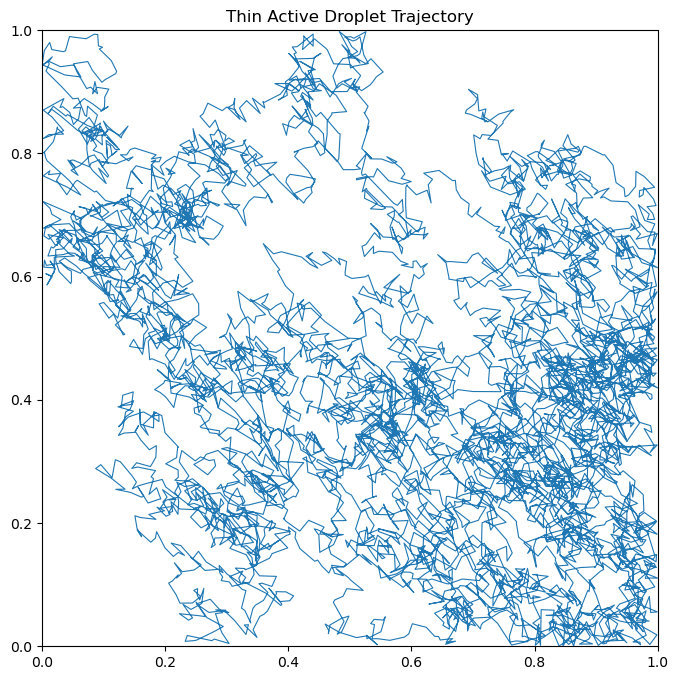

In [ ]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

Nx = 220
Ny = 220

domain = mesh.create_unit_square(
    MPI.COMM_WORLD,
    Nx,
    Ny
)

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial / test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.0015))

# Smaller diffusion -> thinner trail
D = fem.Constant(domain, ScalarType(0.003))

# Emission strength
alpha = 0.00012

# Very narrow source
R = 0.0008

# Self propulsion
beta = 40.0

# Less random wandering
sigma = 0.02

# Trail decay
lam = fem.Constant(domain, ScalarType(0.35))

# =========================================================
# Particle position
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.50))
Y0 = fem.Constant(domain, ScalarType(0.50))

# =========================================================
# Spatial coordinates
# =========================================================

x = ufl.SpatialCoordinate(domain)

# =========================================================
# Gaussian source
# =========================================================

G = (
    1 / (2 * np.pi * R**2)
) * ufl.exp(
    -(
        (x[0] - X0)**2
        + (x[1] - Y0)**2
    ) / (2 * R**2)
)

source = alpha * G

# =========================================================
# Weak form
# =========================================================

a = (
    u*v
    + dt*D*ufl.dot(ufl.grad(u), ufl.grad(v))
    + dt*lam*u*v
) * ufl.dx

L = (
    un*v
    + dt*source*v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# Force integrals
# =========================================================

Fx_form = fem.form(
    G * ufl.grad(uh)[0] * ufl.dx
)

Fy_form = fem.form(
    G * ufl.grad(uh)[1] * ufl.dx
)

# =========================================================
# Visualization setup
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(
    topology,
    cells,
    geometry
)

grid.point_data["u"] = un.x.array.copy()

plotter = pyvista.Plotter(
    off_screen=True,
    window_size=(600, 600)
)

viridis = mpl.colormaps["viridis"]

actor = plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.0008]
)

plotter.view_xy()

plotter.open_gif(
    "thin_active_droplet.gif"
)

# =========================================================
# Trajectory storage
# =========================================================

trajectory_x = []
trajectory_y = []

# =========================================================
# Animation settings
# =========================================================

frame_every = 25

# =========================================================
# Time stepping
# =========================================================

T = 10.0
t = 0.0

num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # =====================================================
    # Solve PDE
    # =====================================================

    problem.solve()

    # =====================================================
    # Update previous solution
    # =====================================================

    un.x.array[:] = uh.x.array

    # =====================================================
    # Compute propulsion force
    # =====================================================

    Fx = fem.assemble_scalar(Fx_form)
    Fy = fem.assemble_scalar(Fy_form)

    # =====================================================
    # Brownian noise
    # =====================================================

    noise_x = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    noise_y = (
        sigma
        * np.sqrt(float(dt.value))
        * np.random.randn()
    )

    # =====================================================
    # Particle dynamics
    # =====================================================

    Xnew = (
        float(X0.value)
        - beta * float(dt.value) * Fx
        + noise_x
    )

    Ynew = (
        float(Y0.value)
        - beta * float(dt.value) * Fy
        + noise_y
    )

    # =====================================================
    # Reflecting boundaries
    # =====================================================

    if Xnew < 0:
        Xnew = -Xnew

    if Xnew > 1:
        Xnew = 2 - Xnew

    if Ynew < 0:
        Ynew = -Ynew

    if Ynew > 1:
        Ynew = 2 - Ynew

    # =====================================================
    # Update particle position
    # =====================================================

    X0.value = ScalarType(Xnew)
    Y0.value = ScalarType(Ynew)

    # =====================================================
    # Save trajectory
    # =====================================================

    trajectory_x.append(Xnew)
    trajectory_y.append(Ynew)

    # =====================================================
    # Visualization update
    # =====================================================

    if step % frame_every == 0:

        scalars = uh.x.array.copy()

        grid.point_data["u"] = scalars

        actor.mapper.scalar_range = (
            0,
            0.0008
        )

        plotter.write_frame()

# =========================================================
# Finish GIF
# =========================================================

plotter.close()

# =========================================================
# Trajectory plot
# =========================================================

trajectory_x = np.array(trajectory_x)
trajectory_y = np.array(trajectory_y)

plt.figure(figsize=(8, 8))

plt.plot(
    trajectory_x,
    trajectory_y,
    linewidth=0.8
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")

plt.title("Thin Active Droplet Trajectory")

plt.show()


100%|██████████| 10000/10000 [1:07:09<00:00,  2.48it/s]


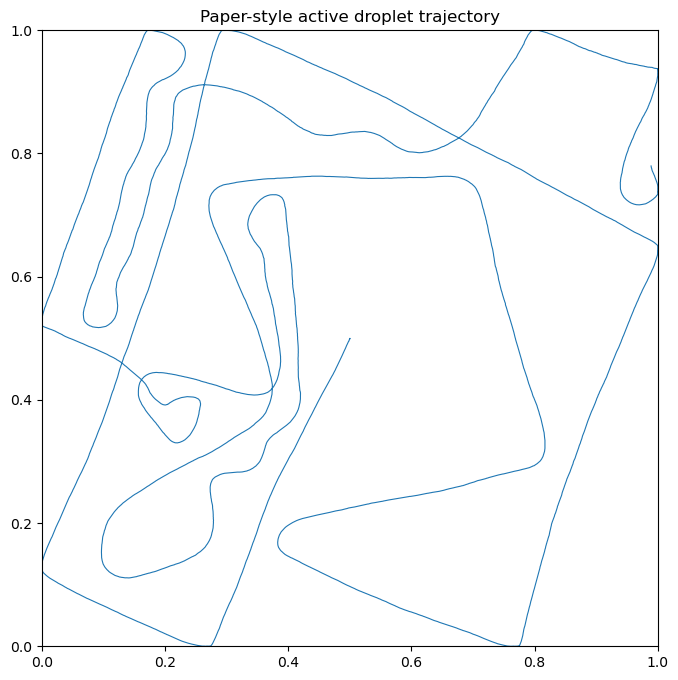

In [1]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
from tqdm import tqdm

from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import ufl
import numpy as np
import pyvista
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Mesh
# =========================================================

Nx = 260
Ny = 260

domain = mesh.create_unit_square(MPI.COMM_WORLD, Nx, Ny)
comm = domain.comm

# =========================================================
# Function space
# =========================================================

V = fem.functionspace(domain, ("Lagrange", 1))

# =========================================================
# Initial condition
# =========================================================

def initial_condition(x):
    return np.zeros_like(x[0])

un = fem.Function(V)
un.interpolate(initial_condition)

uh = fem.Function(V)

# =========================================================
# Trial / test functions
# =========================================================

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# =========================================================
# Time / model parameters
# =========================================================

dt = fem.Constant(domain, ScalarType(0.001))

# Diffusion in the paper-style model
D = fem.Constant(domain, ScalarType(5e-5))

# Particle parameters
beta = 250.0
sigma = 1.0e-6

# Paper-style radius evolution
R0 = 0.020
Rshrink = 0.0005
Rmin = 0.006

# Friction parameter
eta = 1.0

# Source scaling parameter from the paper
delta = 0.08

# =========================================================
# Time-dependent constants
# =========================================================

X0 = fem.Constant(domain, ScalarType(0.50))
Y0 = fem.Constant(domain, ScalarType(0.50))

R = fem.Constant(domain, ScalarType(R0))
alpha = fem.Constant(domain, ScalarType(0.0))
gamma = fem.Constant(domain, ScalarType(1.0))

# =========================================================
# Spatial coordinates
# =========================================================

x = ufl.SpatialCoordinate(domain)

# Local disk around the droplet position
r2 = (x[0] - X0) ** 2 + (x[1] - Y0) ** 2
mask = ufl.conditional(ufl.lt(r2, R * R), 1.0, 0.0)

# 2D Gaussian source, centered at the droplet
G = (1.0 / (2.0 * np.pi * R * R)) * ufl.exp(
    -r2 / (2.0 * R * R)
)

source = alpha * G

# =========================================================
# Weak form
#   ∂t c = D ∇²c + α_t G_Rt(x - X_t)
# =========================================================

a = (
    u * v
    + dt * D * ufl.dot(ufl.grad(u), ufl.grad(v))
) * ufl.dx

L = (
    un * v
    + dt * source * v
) * ufl.dx

# =========================================================
# Linear problem
# =========================================================

problem = LinearProblem(
    a,
    L,
    u=uh,
    petsc_options_prefix="diffusion_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    }
)

# =========================================================
# Force integrals
#   F = ∫_{|x-X_t|<R_t} G_Rt(x-X_t) ∇c_t(x) dx
# =========================================================

Fx_form = fem.form(mask * G * ufl.grad(uh)[0] * ufl.dx)
Fy_form = fem.form(mask * G * ufl.grad(uh)[1] * ufl.dx)

# =========================================================
# Visualization setup
# =========================================================

topology, cells, geometry = plot.vtk_mesh(V)

grid = pyvista.UnstructuredGrid(topology, cells, geometry)
grid.point_data["u"] = un.x.array.copy()

plotter = pyvista.Plotter(off_screen=True, window_size=(600, 600))

viridis = mpl.colormaps["viridis"]

actor = plotter.add_mesh(
    grid,
    cmap=viridis,
    show_edges=False,
    lighting=False,
    clim=[0, 0.001]
)

plotter.view_xy()
plotter.open_gif("paper_style_active_droplet.gif")

# =========================================================
# Trajectory storage
# =========================================================

trajectory_x = []
trajectory_y = []

# =========================================================
# Helper: update paper parameters
# =========================================================

def update_paper_parameters(t):
    Rval = max(R0 - Rshrink * t, Rmin)

    # alpha_t = 3 R_t^2 / delta^3 * |Rdot|
    alphaval = 3.0 * (Rval ** 2) / (delta ** 3) * Rshrink

    # gamma_t = 6 pi eta R_t
    gammaval = 6.0 * np.pi * eta * Rval

    R.value = ScalarType(Rval)
    alpha.value = ScalarType(alphaval)
    gamma.value = ScalarType(gammaval)

    return Rval, alphaval, gammaval

# =========================================================
# Animation settings
# =========================================================

frame_every = 25

# =========================================================
# Time stepping
# =========================================================

T = 10.0
t = 0.0
num_steps = int(T / float(dt.value))

for step in tqdm(range(num_steps)):

    t += float(dt.value)

    # Update paper-style parameters
    Rval, alphaval, gammaval = update_paper_parameters(t)

    # Solve PDE
    problem.solve()

    # Update previous solution
    un.x.array[:] = uh.x.array

    # Compute force-like integrals
    Fx_local = fem.assemble_scalar(Fx_form)
    Fy_local = fem.assemble_scalar(Fy_form)

    Fx = comm.allreduce(Fx_local, op=MPI.SUM)
    Fy = comm.allreduce(Fy_local, op=MPI.SUM)

    # Euler-Maruyama update for droplet position:
    # gamma_t Xdot = -beta R_t^3/delta^3 * F + sqrt(sigma) xi_t
    drift_prefactor = beta * (Rval ** 3) / (delta ** 3) / gammaval

    noise_scale = np.sqrt(sigma * float(dt.value)) / gammaval

    Xnew = (
        float(X0.value)
        - float(dt.value) * drift_prefactor * Fx
        + noise_scale * np.random.randn()
    )

    Ynew = (
        float(Y0.value)
        - float(dt.value) * drift_prefactor * Fy
        + noise_scale * np.random.randn()
    )

    # Reflecting boundaries
    if Xnew < 0:
        Xnew = -Xnew
    if Xnew > 1:
        Xnew = 2 - Xnew

    if Ynew < 0:
        Ynew = -Ynew
    if Ynew > 1:
        Ynew = 2 - Ynew

    X0.value = ScalarType(Xnew)
    Y0.value = ScalarType(Ynew)

    trajectory_x.append(Xnew)
    trajectory_y.append(Ynew)

    # Update visualization occasionally
    if step % frame_every == 0:
        scalars = uh.x.array.copy()
        grid.point_data["u"] = scalars

        actor.mapper.scalar_range = (0.0, max(float(np.max(scalars)), 1e-12))
        plotter.write_frame()

# =========================================================
# Finish GIF
# =========================================================

plotter.close()

# =========================================================
# Trajectory plot
# =========================================================

trajectory_x = np.array(trajectory_x)
trajectory_y = np.array(trajectory_y)

plt.figure(figsize=(8, 8))
plt.plot(trajectory_x, trajectory_y, linewidth=0.8)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.title("Paper-style active droplet trajectory")
plt.show()
